### Module 1 — Import Libraries & Load Dataset

In [1]:
# ===============================================
# Module 1 : Import Libraries & Load Dataset
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

# Load Dataset
df = pd.read_excel("/content/Opportunity_Analysis_Ready.xlsx")

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst Five Rows")
display(df.head())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

Dataset Loaded Successfully

Shape:
(5730, 20)

Columns:
['opportunity_id', 'category', 'code', 'created_at', 'currency_type', 'duration', 'duration_type', 'fee', 'image_link', 'is_archived', 'is_auto_approve', 'last_date_to_apply', 'location', 'long_description', 'microscholarship', 'modified_at', 'name', 'role', 'role_responsibility', 'short_description']

First Five Rows


,opportunity_id,category,code,created_at,currency_type,duration,duration_type,fee,image_link,is_archived,is_auto_approve,last_date_to_apply,location,long_description,microscholarship,modified_at,name,role,role_responsibility,short_description
0,Opportunity#000000000GBD0AX3Z6VYRG7R75,Competition,M636023,2022-08-08 23:06:40,USD,300.0,minutes,0.0,https://www.clipartkey.com/mpngs/m/56-563364_b...,1.0,1.0,2023-07-22 04:26:40,NaN,"Your future is in your hands, truly. Ideate an...",500.0,2023-07-22 04:26:40,Mini Saga 3.0,NaN,NaN,Express yourself in 50-words!
1,Opportunity#000000000GFKZ4N696ZF8V2WM8,Career,A463411,2022-08-08 23:06:40,USD,1.0,years,0.0,https://encrypted-tbn0.gstatic.com/images?q=tb...,1.0,1.0,2023-07-22 04:26:40,NaN,At GlobalShala we believe that experiential le...,100.0,2023-07-22 04:26:40,Virtual Internship Facilitator,Facilitator,Leading and mentoring a group of 5-10 students...,In this role you be impacting young lives whil...
2,Opportunity#0000000010ZFE0ZS22FA3Q62R4,Career,A8848RT,2024-03-09 16:00:00,NaN,30.0,weeks,0.0,https://excelerate-profile-dev.s3.ap-south-1.a...,NaN,0.0,2019-06-08 13:20:00,Work From Home,NaN,0.0,2024-03-09 16:00:00,Careerwishlist Automation 1710333189352,NaN,Testing and debugging,"Short Description, Explore hands-on defensive ..."
3,Opportunity#000000000GG34EPWZAJ6BDPQKP,Internship,I882052,2022-12-02 16:53:20,USD,20.0,minutes,0.0,https://excelerateuserprofile.s3.ap-south-1.am...,1.0,1.0,2023-11-14 22:13:20,NaN,"In this internship, you will help your sponsor...",1000.0,2023-07-22 04:26:40,Digital Marketing - Demo,Social Media Analyst,NaN,Explore the best practices and proven strategi...
4,Opportunity#000000000GQHDFWJ9R1HQJ4WTE,Event,E307640,2022-08-08 23:06:40,USD,3.0,years,0.0,https://excelerateuserprofile.s3.ap-south-1.am...,0.0,1.0,2026-05-28 20:26:40,NaN,As technologies such as social media apps and ...,500.0,2026-05-28 20:26:40,Humanizing Technology: An Introduction to User...,NaN,NaN,Students will learn the fundamentals of user e...



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5730 entries, 0 to 5729
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   opportunity_id       5730 non-null   object        
 1   category             5727 non-null   object        
 2   code                 5729 non-null   object        
 3   created_at           5726 non-null   datetime64[ns]
 4   currency_type        5387 non-null   object        
 5   duration             5721 non-null   float64       
 6   duration_type        5725 non-null   object        
 7   fee                  5726 non-null   float64       
 8   image_link           5723 non-null   object        
 9   is_archived          525 non-null    float64       
 10  is_auto_approve      5727 non-null   float64       
 11  last_date_to_apply   5726 non-null   datetime64[ns]
 12  location             4275 non-null   object        
 13  long_descrip

# Module 2 — Data Cleaning

In [2]:
# ===============================================
# Module 2 : Data Cleaning
# ===============================================

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Convert dates
date_columns = [
    "created_at",
    "modified_at",
    "last_date_to_apply"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Fill missing categorical values

categorical_cols = [
    "category",
    "location",
    "currency_type",
    "role"
]

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

# Fill fee

df["fee"] = df["fee"].fillna(0)

# Fill microscholarship

df["microscholarship"] = df["microscholarship"].fillna(0)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5730 entries, 0 to 5729
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   opportunity_id       5730 non-null   object        
 1   category             5730 non-null   object        
 2   code                 5729 non-null   object        
 3   created_at           5726 non-null   datetime64[ns]
 4   currency_type        5730 non-null   object        
 5   duration             5721 non-null   float64       
 6   duration_type        5725 non-null   object        
 7   fee                  5730 non-null   float64       
 8   image_link           5723 non-null   object        
 9   is_archived          525 non-null    float64       
 10  is_auto_approve      5727 non-null   float64       
 11  last_date_to_apply   5726 non-null   datetime64[ns]
 12  location             5730 non-null   object        
 13  long_description     5386 non-nul

# Module 3 — Dataset Overview

In [3]:
# ===============================================
# Module 3 : Dataset Overview
# ===============================================

print("Number of Opportunities :", len(df))

print("\nNumber of Features :", len(df.columns))

print("\nSummary Statistics")

display(df.describe(include="all"))

print("\nCategory Distribution")

display(df["category"].value_counts())

print("\nLocation Distribution")

display(df["location"].value_counts())

print("\nCurrency Distribution")

display(df["currency_type"].value_counts())

Number of Opportunities : 5730

Number of Features : 20

Summary Statistics


,opportunity_id,category,code,created_at,currency_type,duration,duration_type,fee,image_link,is_archived,is_auto_approve,last_date_to_apply,location,long_description,microscholarship,modified_at,name,role,role_responsibility,short_description
count,5730,5730,5729,5726,5730,5721.000000,5725,5730.000000,5723,525.000000,5727.00000,5726,5730,5386,5730.000000,5726,5730,5730,1079,5730
unique,5730,11,5728,NaN,4,NaN,6,NaN,3770,NaN,NaN,NaN,4,894,NaN,NaN,5570,430,88,838
top,Opportunity#0000000010XFNENX1PXV57SW74,Internship,IZ18WQO,NaN,USD,NaN,weeks,NaN,https://excelerateuserprofile.s3.ap-south-1.am...,NaN,NaN,NaN,Work From Home,"Long Description, In this internship you will ...",NaN,NaN,Secrets To Operational Excellence Course,Unknown,Testing and debugging,"Short Description, Explore hands-on defensive ..."
freq,1,1591,2,NaN,4698,NaN,4286,NaN,1609,NaN,NaN,NaN,2356,3501,NaN,NaN,11,3837,879,3893
mean,NaN,NaN,NaN,2024-06-17 05:11:57.708697088,NaN,24.536095,NaN,57.414834,NaN,0.731429,0.14161,2024-04-05 20:58:01.103737088,NaN,NaN,175.507155,2024-07-20 01:01:43.527768064,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,2022-08-08 23:06:40,NaN,0.000000,NaN,0.000000,NaN,0.000000,0.00000,1970-01-01 00:00:00,NaN,NaN,0.000000,2023-03-28 10:40:00,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,2023-11-14 22:13:20,NaN,12.000000,NaN,0.000000,NaN,0.000000,0.00000,2023-11-14 22:13:20,NaN,NaN,100.000000,2023-11-14 22:13:20,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,2024-03-09 16:00:00,NaN,30.000000,NaN,0.000000,NaN,1.000000,0.00000,2024-07-03 09:46:40,NaN,NaN,120.000000,2024-03-09 16:00:00,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2025-02-19 21:20:00,NaN,30.000000,NaN,0.000000,NaN,1.000000,0.00000,2025-02-19 21:20:00,NaN,NaN,120.000000,2025-02-19 21:20:00,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,2026-05-28 20:26:40,NaN,359.000000,NaN,200000.000000,NaN,1.000000,1.00000,2027-12-28 13:20:00,NaN,NaN,50000.000000,2026-05-28 20:26:40,NaN,NaN,NaN,NaN



Category Distribution


,count
category,
Internship,1591
Career,1087
Competition,734
Course,632
Event,622
Engagement,459
Masterclass,400
Jobsimulation,198
Unknown,3



Location Distribution


,count
location,
Work From Home,2356
Virtual,1918
Unknown,1455
Kolkata,1



Currency Distribution


,count
currency_type,
USD,4698
INR,355
Unknown,343
EUR,334


# Module 4 — Opportunity Creation Trend


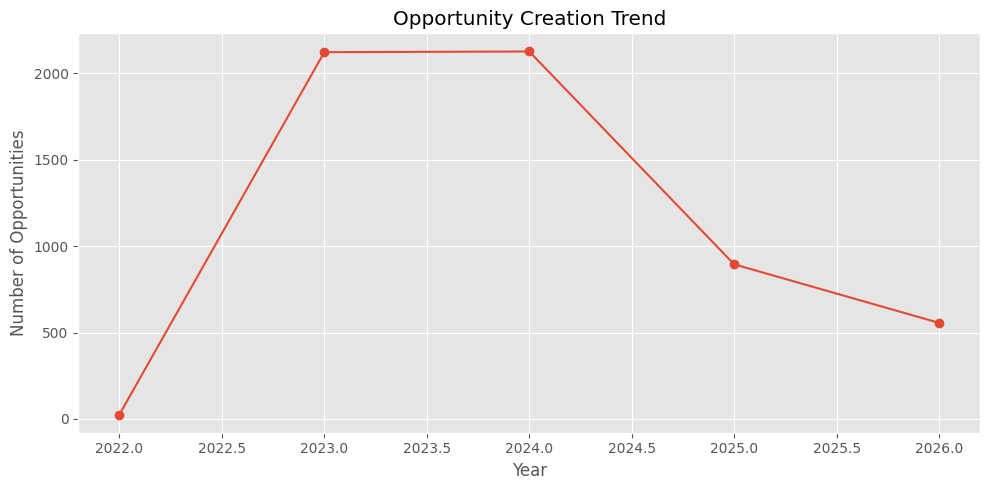

In [5]:
# ===============================================
# Module 4 : Opportunity Trends
# ===============================================

df["Year"] = df["created_at"].dt.year
df["Month"] = df["created_at"].dt.month_name()

yearly = df["Year"].value_counts().sort_index()

plt.figure(figsize=(10,5))

yearly.plot(kind="line", marker="o")

plt.title("Opportunity Creation Trend")

plt.xlabel("Year")

plt.ylabel("Number of Opportunities")

plt.tight_layout()

#plt.savefig("charts/opportunity_trend.png")

plt.show()

# Module 5 — Location Analysis

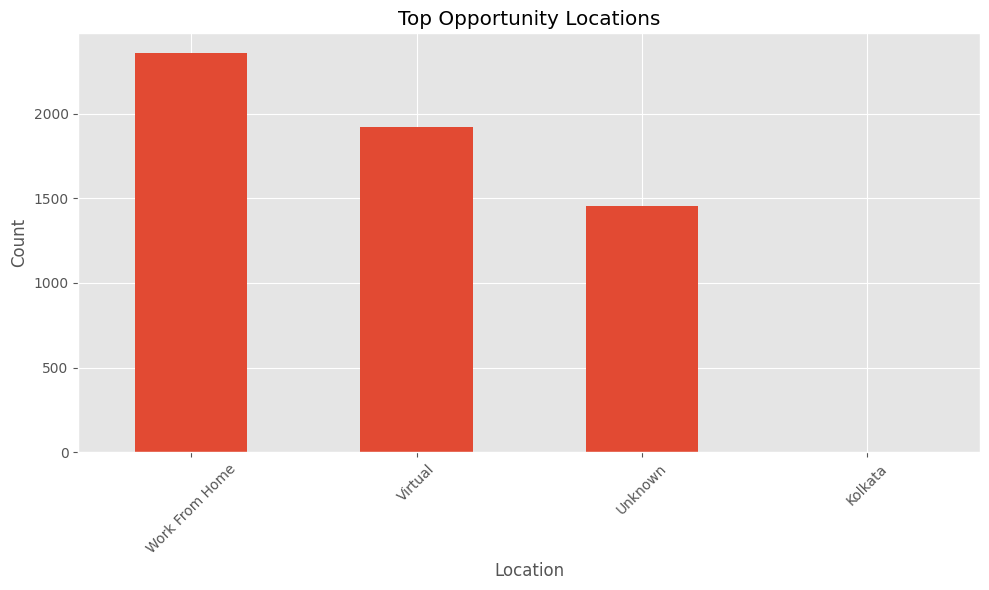

,count
location,
Work From Home,2356
Virtual,1918
Unknown,1455
Kolkata,1


In [7]:
# ===============================================
# Module 5 : Location Analysis
# ===============================================

top_locations = df["location"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_locations.plot(kind="bar")

plt.title("Top Opportunity Locations")

plt.xlabel("Location")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()

#plt.savefig("charts/location_analysis.png")

plt.show()

display(top_locations)

MISSING VALUE ANALYSIS


,Missing Count,Missing Percentage
is_archived,5205,90.84
role_responsibility,4651,81.17
long_description,344,6.00
duration,9,0.16
image_link,7,0.12
duration_type,5,0.09
Month,4,0.07
last_date_to_apply,4,0.07
modified_at,4,0.07
Year,4,0.07


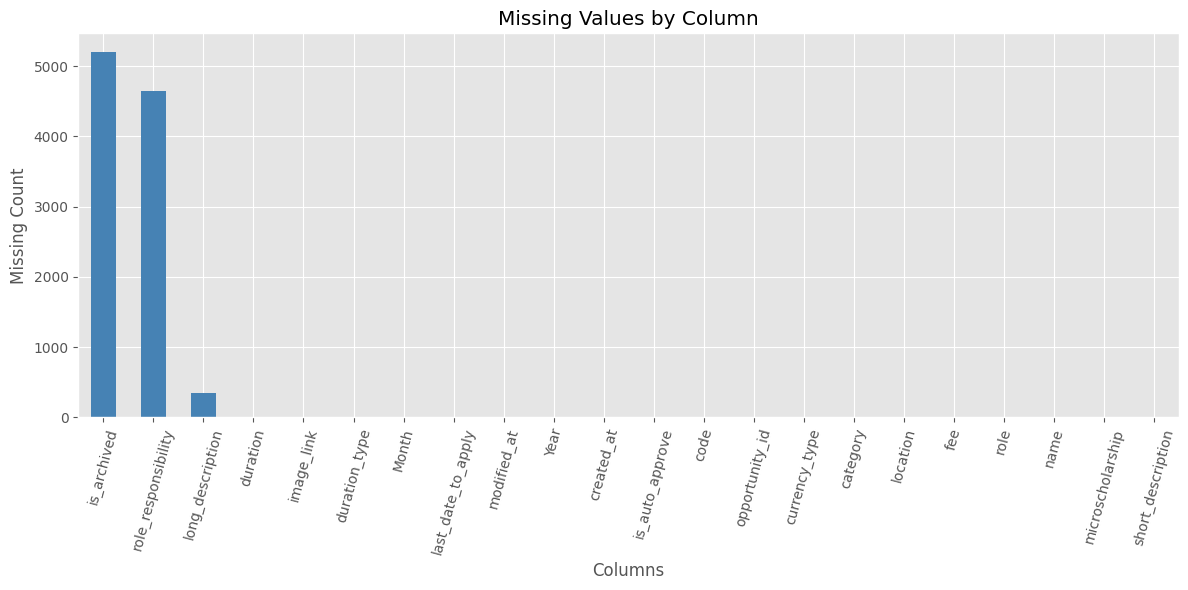


Top Missing Columns
                     Missing Count  Missing Percentage
is_archived                   5205               90.84
role_responsibility           4651               81.17
long_description               344                6.00
duration                         9                0.16
image_link                       7                0.12


In [14]:
# ===============================================
# Module 5A : Missing Value Analysis
# ===============================================

print("="*70)
print("MISSING VALUE ANALYSIS")
print("="*70)

# Missing Values Table
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum()/len(df)*100).round(2)
})

missing_values = missing_values.sort_values(
    by="Missing Count",
    ascending=False
)

display(missing_values)

# Plot Missing Values

plt.figure(figsize=(12,6))

missing_values["Missing Count"].plot(
    kind="bar",
    color="steelblue"
)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Count")
plt.xticks(rotation=75)

plt.tight_layout()

#plt.savefig("charts/missing_values.png")

plt.show()

print("\nTop Missing Columns")
print(missing_values.head())

In [15]:
# ===============================================
# Module 5B : Duplicate Analysis
# ===============================================

print("="*70)
print("DUPLICATE ANALYSIS")
print("="*70)

# Duplicate Rows

duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_rows}")

# Duplicate Opportunity IDs

duplicate_opportunity = df["opportunity_id"].duplicated().sum()

print(f"Duplicate Opportunity IDs : {duplicate_opportunity}")

# Duplicate Codes

duplicate_code = df["code"].duplicated().sum()

print(f"Duplicate Codes : {duplicate_code}")

# Show duplicate codes if available

if duplicate_code > 0:
    print("\nDuplicate Code Records")

    display(
        df[df["code"].duplicated(keep=False)]
        .sort_values("code")
    )
else:
    print("\nNo Duplicate Codes Found.")

print("\nDuplicate Analysis Completed.")

DUPLICATE ANALYSIS
Duplicate Rows : 0
Duplicate Opportunity IDs : 0
Duplicate Codes : 1

Duplicate Code Records


,opportunity_id,category,code,created_at,currency_type,duration,duration_type,fee,image_link,is_archived,...,location,long_description,microscholarship,modified_at,name,role,role_responsibility,short_description,Year,Month
1604,Opportunity#00000000106K5PNHK4D7RMPZB6,Internship,IZ18WQO,2025-10-09 08:53:20,USD,1.0,months,0.0,https://excelerate-profile-dev.s3.ap-south-1.a...,NaN,...,Work From Home,Opportunity name Assignment Review,120.0,2025-10-09 08:53:20,Opportunity name Assignment Review,Role,NaN,Opportunity name Assignment Review,2025.0,October
1605,Opportunity#00000000106K5PNHK4D7RMPZB611,Internship,IZ18WQO,2025-10-09 08:53:20,USD,1.0,months,0.0,https://excelerate-profile-dev.s3.ap-south-1.a...,NaN,...,Work From Home,Opportunity name Assignment Review,120.0,2025-10-09 08:53:20,Opportunity name Assignment Review,Role,NaN,Opportunity name Assignment Review,2025.0,October



Duplicate Analysis Completed.


In [16]:
# ===============================================
# Module 5C : Data Type Summary
# ===============================================

print("="*70)
print("DATA TYPE SUMMARY")
print("="*70)

numeric_cols = df.select_dtypes(include=["number"]).columns

categorical_cols = df.select_dtypes(include=["object"]).columns

datetime_cols = df.select_dtypes(include=["datetime"]).columns

boolean_cols = [
    col for col in df.columns
    if "is_" in col
]

text_cols = [
    "name",
    "short_description",
    "long_description",
    "role_responsibility"
]

summary = pd.DataFrame({
    "Feature Type":[
        "Numeric",
        "Categorical",
        "Datetime",
        "Boolean",
        "Text"
    ],
    "Count":[
        len(numeric_cols),
        len(categorical_cols),
        len(datetime_cols),
        len(boolean_cols),
        len(text_cols)
    ]
})

display(summary)

print("\nNumeric Columns")
print(list(numeric_cols))

print("\nCategorical Columns")
print(list(categorical_cols))

print("\nDatetime Columns")
print(list(datetime_cols))

print("\nBoolean Columns")
print(boolean_cols)

print("\nText Columns")
print(text_cols)

DATA TYPE SUMMARY


,Feature Type,Count
0,Numeric,6
1,Categorical,13
2,Datetime,3
3,Boolean,2
4,Text,4



Numeric Columns
['duration', 'fee', 'is_archived', 'is_auto_approve', 'microscholarship', 'Year']

Categorical Columns
['opportunity_id', 'category', 'code', 'currency_type', 'duration_type', 'image_link', 'location', 'long_description', 'name', 'role', 'role_responsibility', 'short_description', 'Month']

Datetime Columns
['created_at', 'last_date_to_apply', 'modified_at']

Boolean Columns
['is_archived', 'is_auto_approve']

Text Columns
['name', 'short_description', 'long_description', 'role_responsibility']


# Module 6 — Opportunity Category Analysis

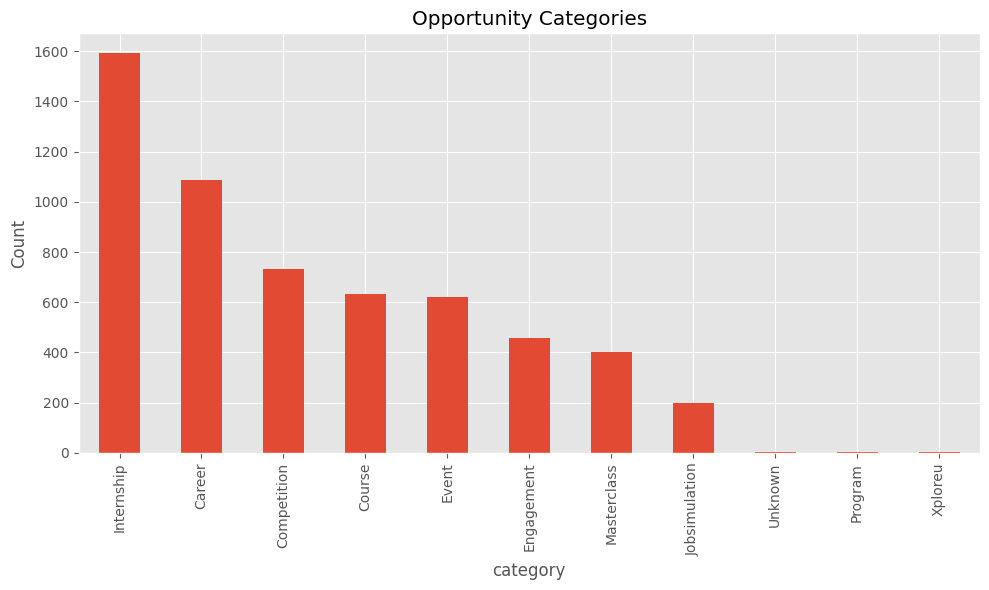

,count
category,
Internship,1591
Career,1087
Competition,734
Course,632
Event,622
Engagement,459
Masterclass,400
Jobsimulation,198
Unknown,3


In [8]:
# ===============================================
# Module 6 : Category Analysis
# ===============================================

category = df["category"].value_counts()

plt.figure(figsize=(10,6))

category.plot(kind="bar")

plt.title("Opportunity Categories")

plt.ylabel("Count")

plt.tight_layout()

#plt.savefig("charts/category_analysis.png")

plt.show()

display(category)

# Module 7 — Fee Analysis

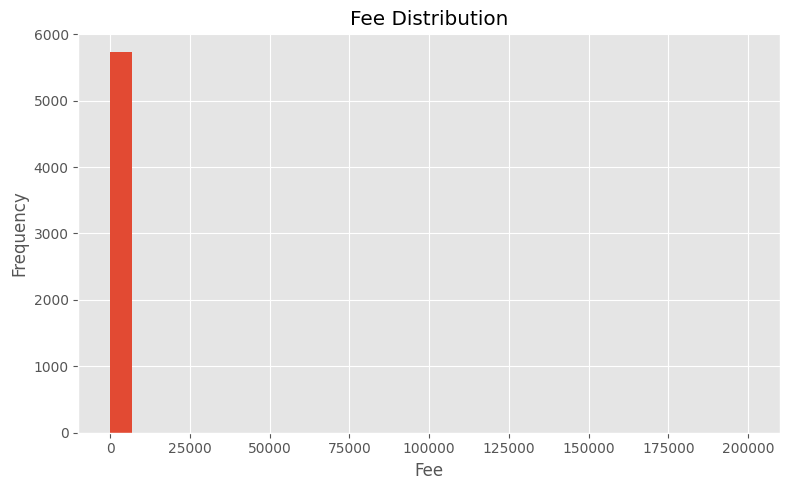

count      5730.000000
mean         57.414834
std        2791.143073
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      200000.000000
Name: fee, dtype: float64


In [9]:
# ===============================================
# Module 7 : Fee Analysis
# ===============================================

plt.figure(figsize=(8,5))

plt.hist(df["fee"], bins=30)

plt.title("Fee Distribution")

plt.xlabel("Fee")

plt.ylabel("Frequency")

plt.tight_layout()

#plt.savefig("charts/fee_distribution.png")

plt.show()

print(df["fee"].describe())

# Module 8 — Microscholarship Analysis

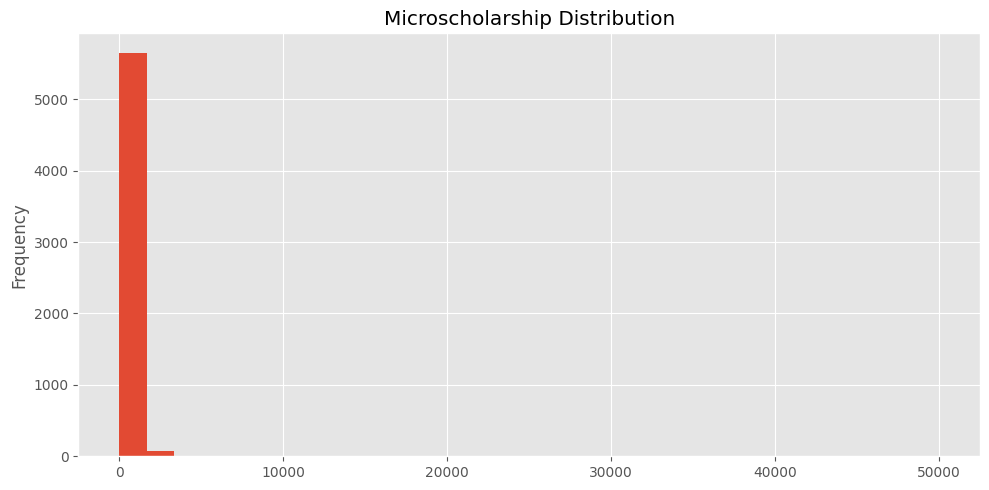

count     5730.000000
mean       175.507155
std        832.385040
min          0.000000
25%        100.000000
50%        120.000000
75%        120.000000
max      50000.000000
Name: microscholarship, dtype: float64


In [10]:
# ===============================================
# Module 8 : Microscholarship Analysis
# ===============================================

plt.figure(figsize=(10,5))

df["microscholarship"].plot(kind="hist", bins=30)

plt.title("Microscholarship Distribution")

plt.tight_layout()

#plt.savefig("charts/microscholarship_distribution.png")

plt.show()

print(df["microscholarship"].describe())

# Module 9 — Correlation & Outlier Detection

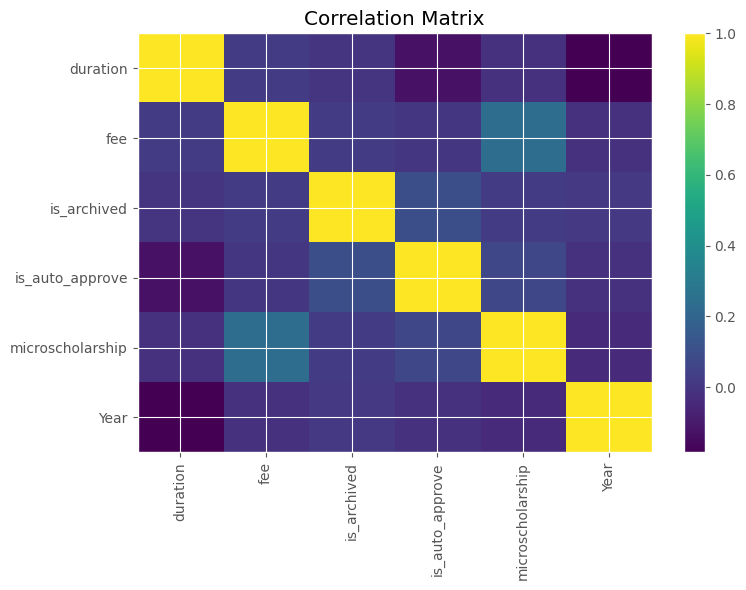

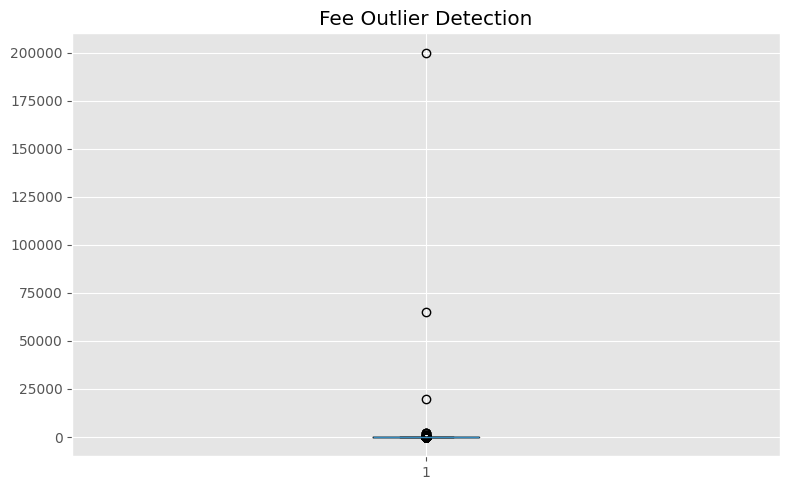

LOGICAL CONSISTENCY CHECKS

Negative Fee Records : 0

Invalid Duration Records (<=0): 3


,opportunity_id,name,duration
1433,Opportunity#0000000010VJC7AS6GQAR6PRZE,Team B Comp. AA,0.0
3615,Opportunity#0000000010DRH1Q3QYN9WYH4QF,Qui iure quo tempora,0.0
4796,Opportunity#0000000010NMCAB55DP4PWDY6D,Testing Checks by MS,0.0



Deadline Before Creation Date : 361


,opportunity_id,name,created_at,last_date_to_apply
2,Opportunity#0000000010ZFE0ZS22FA3Q62R4,Careerwishlist Automation 1710333189352,2024-03-09 16:00:00,2019-06-08 13:20:00
8,Opportunity#0000000010YHJCSGAKECPBFQ65,Course Automation 1740727622332,2025-02-19 21:20:00,2019-06-08 13:20:00
9,Opportunity#0000000010ZNX2EXET8MGC9F7B,Careerwishlist Automation 1701751082558,2023-11-14 22:13:20,2019-06-08 13:20:00
96,Opportunity#0000000010FCVD65SWH9EDEREB,Engagement Automation 1768381468122,2026-02-02 02:40:00,2019-06-08 13:20:00
108,Opportunity#000000001008KA64Q5B4SYZAVE,Careerwishlist Automation 1714724256391,2024-03-09 16:00:00,2019-06-08 13:20:00
...,...,...,...,...
5698,Opportunity#0000000010ZZTEHSZVVQED5M1V,Engagement Role,2025-02-19 21:20:00,2023-07-22 04:26:40
5702,Opportunity#0000000010YQC60E3FMCXXQTGN,Event Automation 1703237359996,2023-11-14 22:13:20,2019-06-08 13:20:00
5718,Opportunity#0000000010ZKXH1KJTS4K7D9P2,course master wishlist,2025-10-09 08:53:20,2019-06-08 13:20:00
5719,Opportunity#0000000010TZF14AAWKD0WZPRE,Event Automation 1709191993846,2024-03-09 16:00:00,2019-06-08 13:20:00



Logical Consistency Check Completed.


In [13]:
# ===============================================
# Module 9 : Correlation
# ===============================================

numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

plt.figure(figsize=(8,6))

plt.imshow(corr, aspect="auto")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.title("Correlation Matrix")

plt.tight_layout()

#plt.savefig("charts/correlation_heatmap.png")

plt.show()

plt.figure(figsize=(8,5))

plt.boxplot(df["fee"].dropna())

plt.title("Fee Outlier Detection")

plt.tight_layout()

#plt.savefig("charts/fee_boxplot.png")

plt.show()

# ===============================================
# Module 9A : Logical Consistency Checks
# ===============================================

print("="*70)
print("LOGICAL CONSISTENCY CHECKS")
print("="*70)

# -----------------------------
# Negative Fees
# -----------------------------

negative_fee = df[df["fee"] < 0]

print(f"\nNegative Fee Records : {len(negative_fee)}")

if len(negative_fee) > 0:
    display(negative_fee)

# -----------------------------
# Zero / Negative Duration
# -----------------------------

invalid_duration = df[df["duration"] <= 0]

print(f"\nInvalid Duration Records (<=0): {len(invalid_duration)}")

if len(invalid_duration) > 0:
    display(
        invalid_duration[
            [
                "opportunity_id",
                "name",
                "duration"
            ]
        ]
    )

# -----------------------------
# Deadline Before Creation
# -----------------------------

date_error = df[
    df["last_date_to_apply"] <
    df["created_at"]
]

print(f"\nDeadline Before Creation Date : {len(date_error)}")

if len(date_error) > 0:

    display(
        date_error[
            [
                "opportunity_id",
                "name",
                "created_at",
                "last_date_to_apply"
            ]
        ]
    )

print("\nLogical Consistency Check Completed.")

# Module 10 — Key Findings

In [12]:
# ===============================================
# Module 10 : Key Findings
# ===============================================

print("="*60)

print("KEY FINDINGS")

print("="*60)

print(f"Total Opportunities : {len(df)}")

print(f"Most Common Category : {df['category'].mode()[0]}")

print(f"Most Common Location : {df['location'].mode()[0]}")

print(f"Average Fee : {df['fee'].mean():.2f}")

print(f"Maximum Microscholarship : {df['microscholarship'].max()}")

print(f"Earliest Opportunity : {df['created_at'].min()}")

print(f"Latest Opportunity : {df['created_at'].max()}")

KEY FINDINGS
Total Opportunities : 5730
Most Common Category : Internship
Most Common Location : Work From Home
Average Fee : 57.41
Maximum Microscholarship : 50000.0
Earliest Opportunity : 2022-08-08 23:06:40
Latest Opportunity : 2026-05-28 20:26:40
